# Estimate ancestry from five SNPs

Suppose two source populations have known allele frequencies at five SNPs. We observe one person's genotype. Which source makes these genotypes more likely?

For each allele copy, the model chooses a source and then draws an allele using that source's frequency. For person $i$, let $q_{ki}$ be the chance of choosing source $k$ and let $p_{\ell k}$ be its allele frequency at SNP $\ell$. Independent draws of the two allele copies give

$$
f_{\ell i}=\sum_k p_{\ell k}q_{ki},\qquad
x_{\ell i}\mid P,Q\sim\operatorname{Binomial}(2,f_{\ell i}).
$$

Before running the calculation, we expect these five genotypes to favor source 1 in Pritchard Figure 3.12. We treat the five SNPs as independent conditional on their source frequencies, so their genotype probabilities multiply. With known $P$, we can calculate the likelihood for a pure source or any mixture. Fitting unknown $P$ and $Q$ jointly is the larger problem addressed by ancestry models such as STRUCTURE and ADMIXTURE.

In [1]:
genotype <- c(0, 2, 1, 2, 0)
P <- cbind(
  source_1 = c(0.3, 0.8, 0.6, 0.6, 0.2),
  source_2 = c(0.6, 0.5, 0.3, 0.8, 0.6)
)

stopifnot(all(genotype %in% 0:2), all(P >= 0), all(P <= 1))

genotype_likelihood <- function(q_source_1) {
  f <- q_source_1 * P[, 1] + (1 - q_source_1) * P[, 2]
  prod(dbinom(genotype, size = 2, prob = f))
}

pure_likelihood <- c(
  source_1 = genotype_likelihood(1),
  source_2 = genotype_likelihood(0)
)
prior <- c(source_1 = 0.5, source_2 = 0.5)
posterior <- prior * pure_likelihood / sum(prior * pure_likelihood)

data.frame(source = names(posterior), likelihood = pure_likelihood,
           posterior = posterior)
stopifnot(abs(sum(posterior) - 1) < 1e-12,
          abs(pure_likelihood[1] - 0.03468165) < 1e-7,
          abs(pure_likelihood[2] - 0.00172032) < 1e-7)

,source,likelihood,posterior
,<chr>,<dbl>,<dbl>
source_1,source_1,0.03468165,0.95274102
source_2,source_2,0.00172032,0.04725898


For two pure-source choices with equal prior probabilities, source 1 has about $0.95$ posterior probability. This reproduces Pritchard Figure 3.12. A posterior probability for these two choices is not an estimate that the person has $95\%$ ancestry from source 1.

## Allow both sources

Now let $q$ be the person's ancestry proportion from source 1, with $1-q$ from source 2. The same binomial likelihood applies after replacing each source frequency by $q p_{\ell 1}+(1-q)p_{\ell 2}$. We expect this five-SNP example to favor values near $q=1$. Five SNPs cannot estimate a person's ancestry precisely.

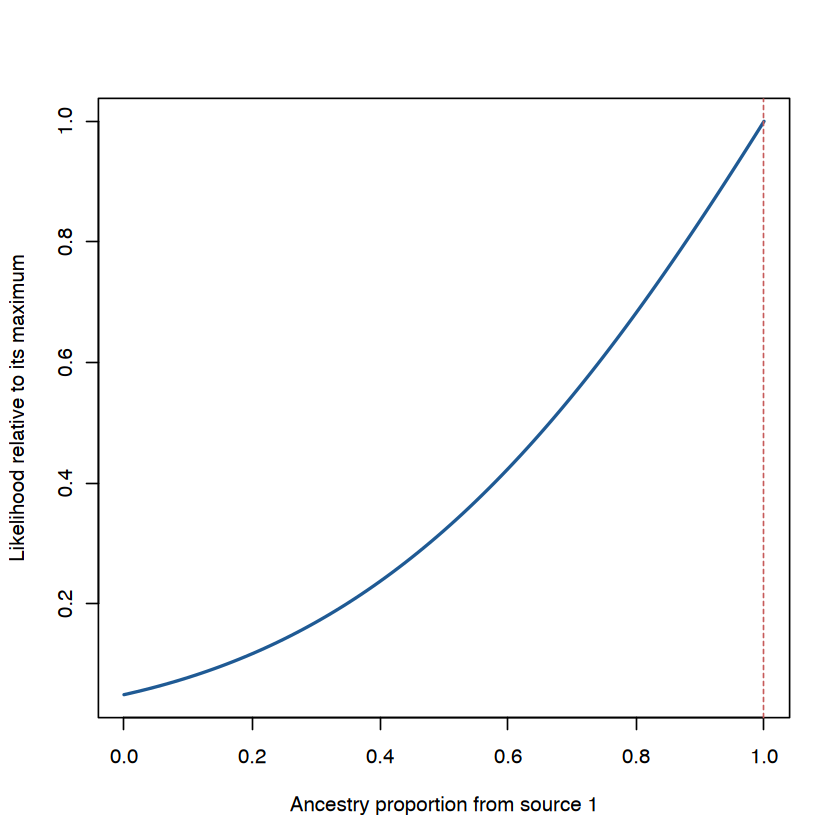

In [2]:
q_grid <- seq(0, 1, by = 0.01)
likelihood <- vapply(q_grid, genotype_likelihood, numeric(1))
best_q <- q_grid[which.max(likelihood)]

plot(q_grid, likelihood / max(likelihood), type = "l", lwd = 2,
     col = "#1F5A94", xlab = "Ancestry proportion from source 1",
     ylab = "Likelihood relative to its maximum")
abline(v = best_q, col = "#C75B5B", lty = 2)

stopifnot(best_q >= 0.95, all(likelihood >= 0))

The maximum is near a pure source-1 model. With more sources, $q_i$ becomes a vector whose entries are nonnegative and sum to one. The weighted frequency still has the same form, $f_{\ell i}=\sum_k p_{\ell k}q_{ki}$. The example below uses an illustrative third source to check that arithmetic; it does not claim that a third source was measured in Figure 3.12.

In [3]:
P_three <- cbind(P, source_3 = c(0.4, 0.2, 0.8, 0.1, 0.7))
q_three <- c(0.2, 0.3, 0.5)
f_three <- as.vector(P_three %*% q_three)

stopifnot(abs(sum(q_three) - 1) < 1e-12,
          all(f_three >= 0), all(f_three <= 1))
data.frame(SNP = 1:5, weighted_frequency = f_three)

SNP,weighted_frequency
<int>,<dbl>
1,0.44
2,0.41
3,0.61
4,0.41
5,0.57


Known source frequencies make the small calculation possible. In an unlabeled sample, the allele-frequency matrix $P$ and ancestry-proportion matrix $Q$ must be estimated from the genotype pattern. Their fitted values depend on the selected number of sources $K$ and the people sampled. The five-SNP calculation shows the likelihood that makes that larger model possible; it does not reproduce either software package.

**Source.** Jonathan Pritchard, *An Owner's Guide to the Human Genome*, [Section 3.1](https://web.stanford.edu/group/pritchardlab/HGbook/ReleaseV1.1/HGBook-V1.1-ch3.1.pdf), especially Figures 3.9–3.15. The five genotypes and two source-frequency vectors reproduce Figure 3.12. The continuous mixture likelihood and the illustrative third source extend that published toy calculation.